# Introducción a la Clasificación y Fronteras de Decisión

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/01_introduccion_clasificacion.ipynb)


## Objetivos


- Comprender el paradigma de clasificación en Machine Learning y su formulación matemática.
- Diferenciar conceptualmente entre los distintos enfoques (geométrico, probabilístico, lógico) para trazar fronteras de decisión.
- Entender el dilema central del aprendizaje: el *Trade-off* Sesgo-Varianza.
- Incorporar el concepto de "Costo Computacional" evaluando tiempos de entrenamiento vs. inferencia.



## Prerrequisitos


- Comprensión de Análisis Exploratorio de Datos (EDA).
- Entendimiento de las métricas básicas de evaluación (Accuracy, Precision, Recall).
- Haber completado: [Métricas de Evaluación Básicas](../01_introduccion/03_metricas_evaluacion_basicas.ipynb).

---



## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## Introducción Teórica



El problema de **Clasificación** consiste en asignar una etiqueta discreta (una categoría) a una observación basándonos en ejemplos previos. Predecir si un correo es *Spam* o *No Spam*, o si un paciente está *Sano* o *Enfermo*, son ejemplos clásicos.

Matemáticamente, buscamos aproximar una función $f$ tal que:

$$ y = f(X) $$

Donde:
- $X$ es el vector de características (*features*) o entrada.
- $y$ pertenece a un conjunto discreto de clases, por ejemplo $y \in \{0, 1\}$ (Clasificación Binaria).

Pero, ¿qué significa realmente "aprender" a clasificar para una computadora?



### La Intuición Geométrica: Dibujando Fronteras



Podemos imaginar que cada característica de nuestros datos son una dimensión espacial. Si tenemos dos variables, los datos viven en un plano 2D. El trabajo de cualquier algoritmo de clasificación es, en esencia, **dibujar una frontera de decisión** (*Decision Boundary*) en ese espacio. De un lado de la frontera, predecirá "Clase A"; del otro, "Clase B".

Los algoritmos difieren fundamentalmente en **cómo** trazan esta frontera:
1. **Enfoque Probabilístico:** Calcula la probabilidad de pertenencia a una clase y aplica un umbral. Suele generar fronteras suaves o lineales. (Ej: Regresión Logística).
2. **Enfoque Lógico:** Crea una serie de reglas *If-Else* que cortan el espacio de forma ortogonal (en ángulos rectos). (Ej: Árboles de Decisión).
3. **Enfoque Basado en Distancias/Memoria:** No asume una forma matemática global, sino que clasifica un punto nuevo mirando a sus "vecinos" más cercanos en el espacio. (Ej: K-Nearest Neighbors).
4. **Enfoque Geométrico Puro:** Busca el hiperplano óptimo que maximice la separación física entre las clases. (Ej: Support Vector Machines).



### El Dilema Central: Sesgo vs. Varianza



Al dibujar esta frontera, nos enfrentamos al problema más importante del Machine Learning: el *Trade-off* Sesgo-Varianza.

- **Alto Sesgo (Subajuste / *Underfitting*):** El modelo asume una regla demasiado simple (ej. una línea recta) para un problema complejo. Fracasa tanto en los datos de entrenamiento como en los nuevos.
- **Alta Varianza (Sobreajuste / *Overfitting*):** El modelo es tan flexible que memoriza el "ruido" exacto de los datos de entrenamiento. Obtiene un 100% de precisión en el laboratorio, pero fracasa estrepitosamente en producción cuando llegan datos ligeramente distintos.
- **El Punto Dulce (Generalización):** El modelo captura el patrón subyacente ignorando el ruido estocástico.



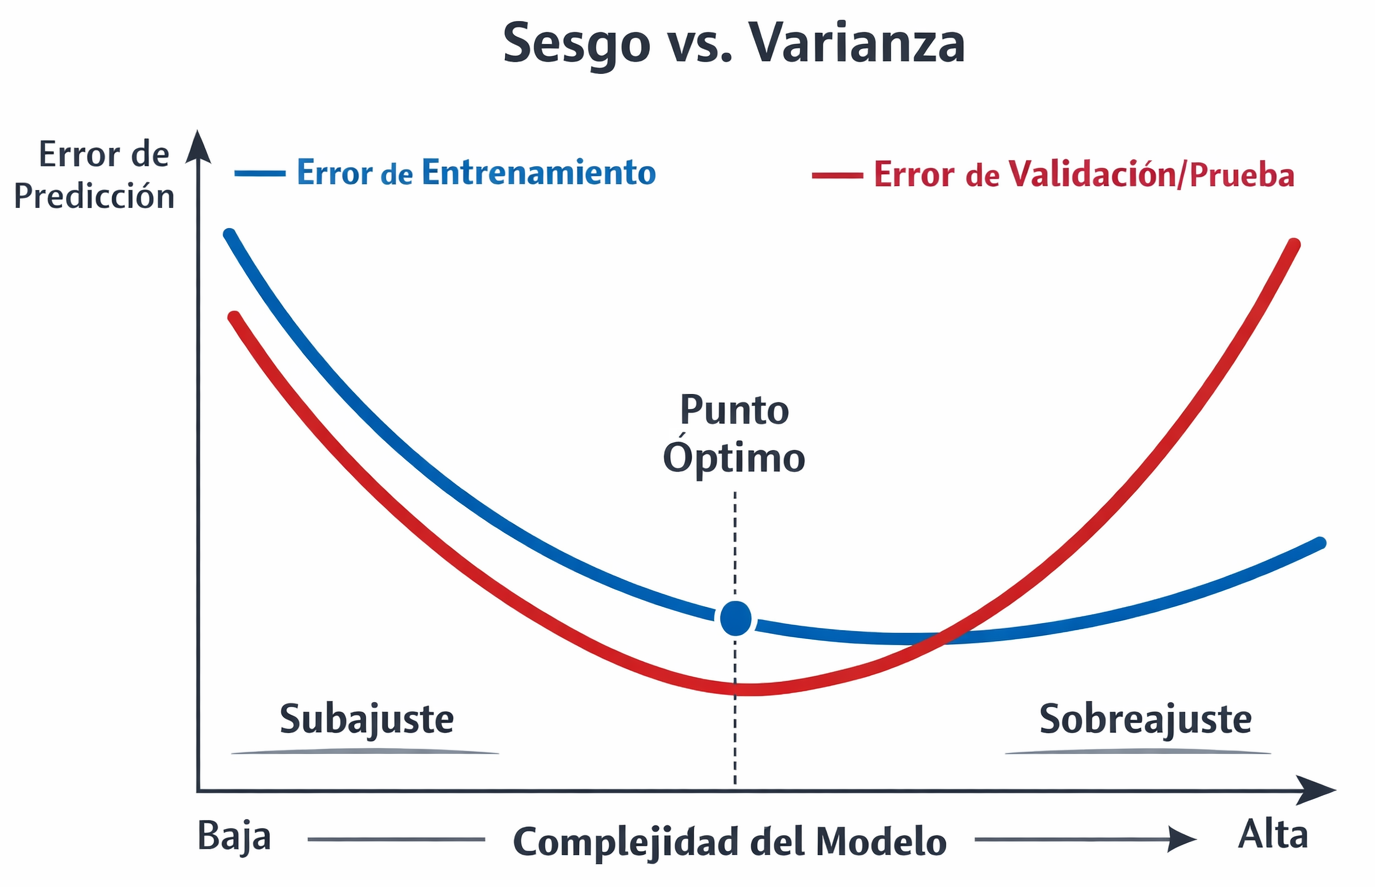

## Desarrollo e Implementación



Vamos a visualizar cómo los distintos algoritmos entienden el mundo trazando sus fronteras de decisión sobre un dataset sintético en 2D (dos lunas entrelazadas con ruido).

A nivel de ingeniería, no solo nos importa que el modelo "acierte", sino **cuánto cuesta** hacer que aprenda y cuánto tarda en emitir una respuesta. Por ello, mediremos los tiempos de entrenamiento e inferencia. Realizando así una comparación "más completa"....



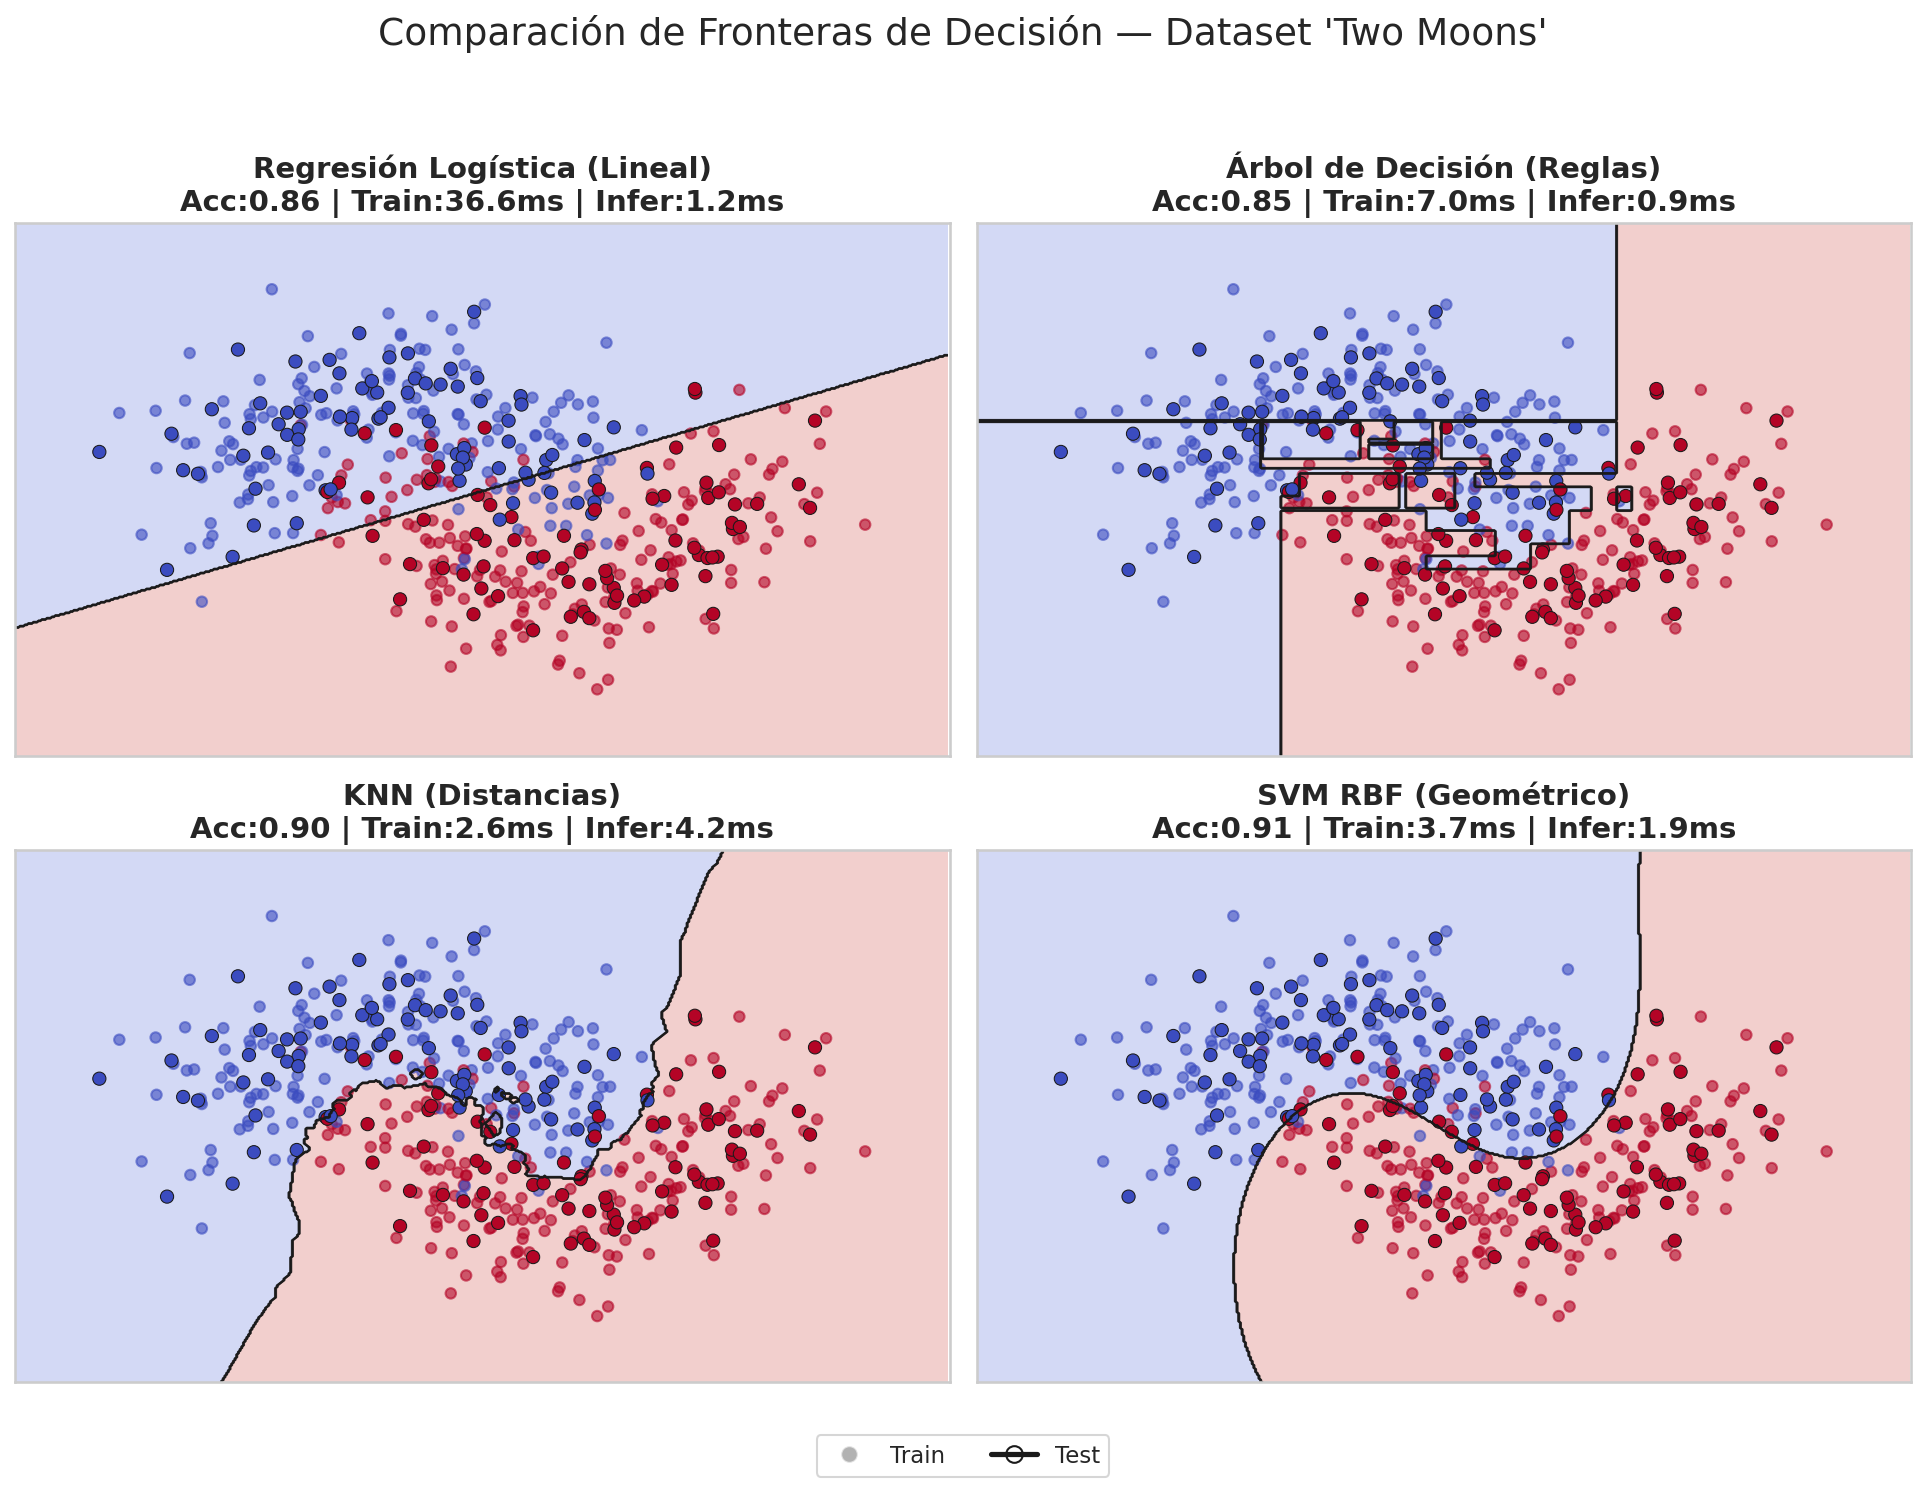

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.lines import Line2D

# Dataset sintético con ruido (no linealmente separable)
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelos base (representando los 4 enfoques distintos)
models = {
    "Regresión Logística (Lineal)": LogisticRegression(),
    "Árbol de Decisión (Reglas)": DecisionTreeClassifier(max_depth=None, random_state=42),
    "KNN (Distancias)": KNeighborsClassifier(5),
    "SVM RBF (Geométrico)": SVC(kernel="rbf", C=1.0, random_state=42)
}

# Malla para las fronteras de decisión
h = 0.01
xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(xmin, xmax, h), np.arange(ymin, ymax, h))

def plot_boundary(clf, ax, title):
    # Función para trazar frontera y medir tiempos
    t=time.time(); clf.fit(Xtr,ytr); train=time.time()-t
    t=time.time(); acc=clf.score(Xte,yte); infer=time.time()-t

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap=plt.cm.coolwarm
    ax.contourf(xx,yy,Z,alpha=.25,cmap=cmap)
    ax.contour(xx,yy,Z,colors="k",linewidths=.8,alpha=.6)

    ax.scatter(Xtr[:,0],Xtr[:,1],c=ytr,cmap=cmap,s=25,alpha=.6)
    ax.scatter(Xte[:,0],Xte[:,1],c=yte,cmap=cmap,s=40,edgecolors="k",linewidth=.5)

    ax.set(xlim=(xmin,xmax),ylim=(ymin,ymax),xticks=[],yticks=[],
           title=f"{title}\nAcc:{acc:.2f} | Train:{train*1e3:.1f}ms | Infer:{infer*1e3:.1f}ms")

# Visualización comparativa
fig,axs=plt.subplots(2,2,figsize=(13,10))
fig.suptitle("Comparación de Fronteras de Decisión — Dataset 'Two Moons'",fontsize=18)

for ax,(name,model) in zip(axs.ravel(),models.items()):
    plot_boundary(model,ax,name)

# Leyenda global
fig.legend([Line2D([0],[0],marker='o',color='w',markerfacecolor='gray',markersize=8,alpha=0.6,),
            Line2D([0],[0],marker='o',color='k',markerfacecolor='none',markersize=8)],
           ["Train","Test"],loc="lower center",ncol=2)

plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()

## Resultados y Discusión



El análisis de la imagen superior revela las "personalidades" de cada algoritmo y sus implicancias en producción:

1. **Regresión Logística (Alto Sesgo):** Solo puede trazar una línea recta. Como el problema es curvo, su rendimiento es pobre. Sin embargo, observar sus tiempos: la inferencia toma microsegundos porque la ecuación matemática resultante es minúscula.
2. **Árbol de Decisión (Alta Varianza):** Al no limitarle la profundidad (`max_depth=None`), el árbol cortó el espacio en rectángulos minúsculos para memorizar cada punto de entrenamiento. Se nota en las "islas" aisladas. Esto es un claro ejemplo de **Overfitting**.
3. **K-Nearest Neighbors (KNN):** Dibuja fronteras extremadamente orgánicas. Pero, mirar los tiempos: el entrenamiento es casi instantáneo (`2 ms`, porque solo guarda los datos en memoria), pero **la inferencia es la más lenta**. En producción, para predecir un dato nuevo, debe calcular la distancia contra todos los datos históricos. Terrible para sistemas en tiempo real con millones de registros (*si hay muchos datos, "juega" en contra para el tiempo de predicción*).
4. **SVM con Kernel RBF (Equilibrio):** Encuentra una frontera suave y generalizable. Suele dar el mejor *Accuracy* en problemas complejos, pero entrenar un SVM en un dataset masivo puede tardar horas debido a su complejidad matemática subyacente.

**⚠️ El Peligro de la Evaluación Ingenua**

Si hubiéramos medido el *Accuracy* usando los mismos datos de entrenamiento, el Árbol de Decisión y el KNN (con K=1) habrían obtenido un 100%. ¡Parecerían los mejores modelos! Esta es la trampa del *Data Snooping*. **Jamás se debe evaluar un modelo con los datos que usó para entrenarse.**

---



## Exploración Interactiva: Visual ML



Los gráficos estáticos son útiles para una foto fija, pero para desarrollar una verdadera intuición de qué pasa, por qué, cómo..., se necesita ver cómo reaccionan estas fronteras en tiempo real cuando se modifican los hiperparámetros de un modelo dado, el tipo de problema (datos con fronteras simples o complejas), el nivel de ruido, cuánto se usa para entrenar y validar, etc.

Para ello, desarrollamos **Visual ML**, un explorador interactivo diseñado específicamente para acompañar este material.

[![Live Demo](https://img.shields.io/badge/Live-Demo-FF4B4B?logo=streamlit&logoColor=white)](https://visual-ml.streamlit.app/)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/visual-ml/blob/main/notebooks/visual_ml_colab.ipynb)



Captura demostrativa de la interfaz:

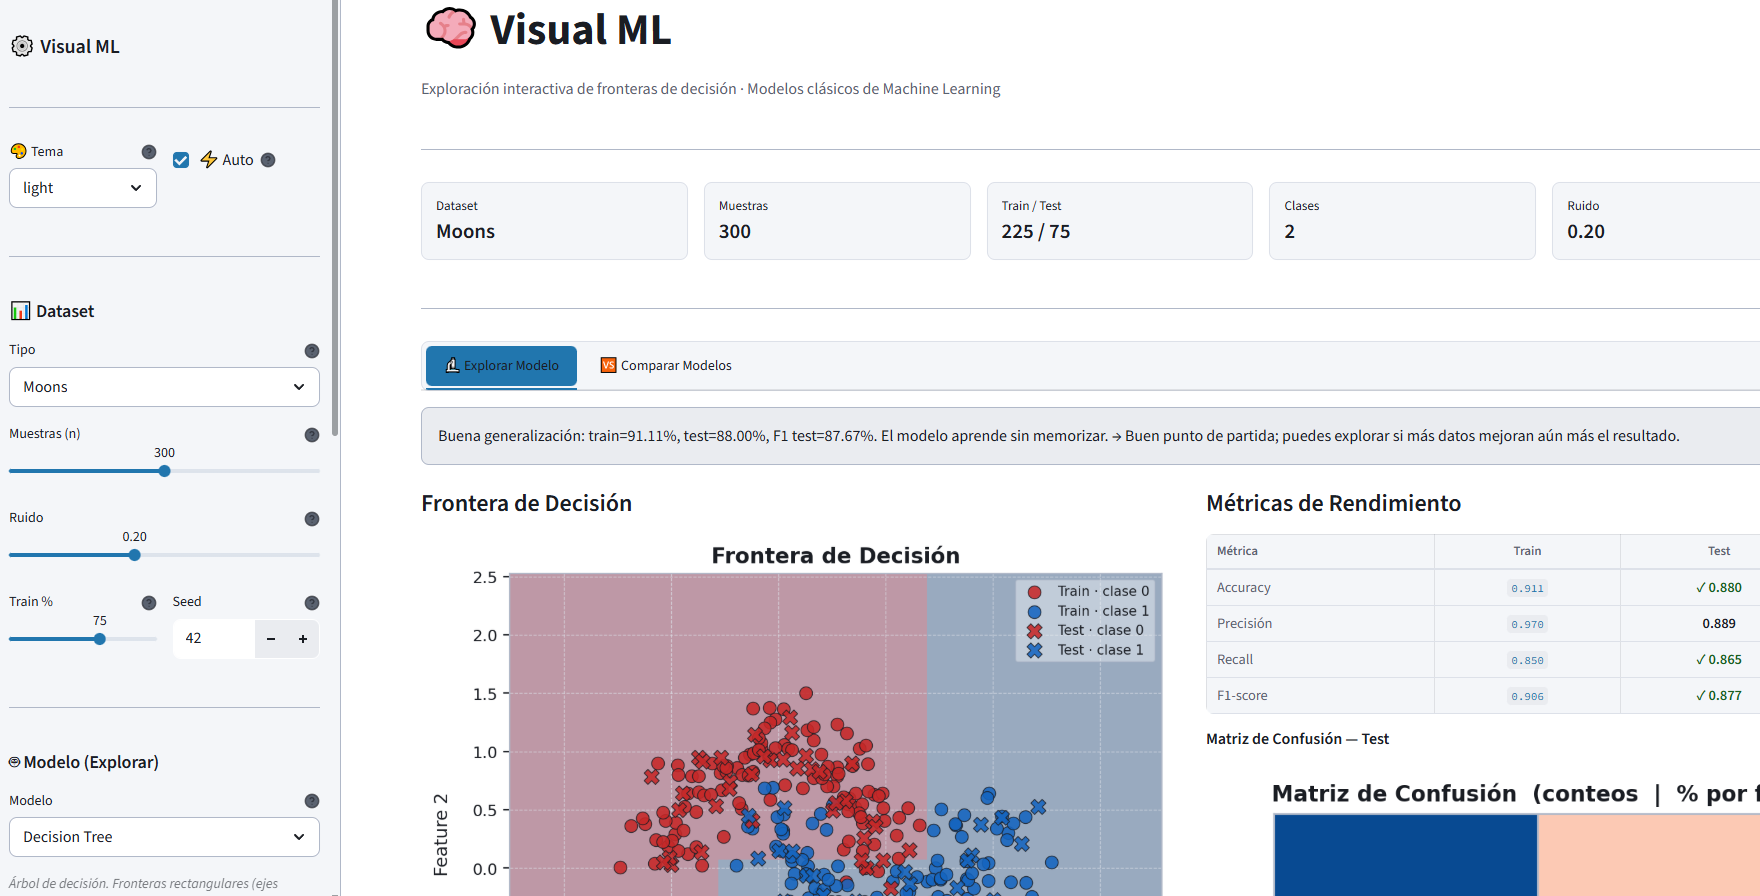

### ¿Qué se puede hacer en Visual ML?


Te invitamos a abrir la aplicación y realizar los siguientes experimentos antes de pasar al próximo notebook:
1. **Provocar Overfitting:** Seleccionar el dataset *Moons*, eligir el modelo *Decision Tree* y subir el parámetro `max_depth` al máximo. Observar cómo la aplicación te lanza una alerta pedagógica de "Memorización".
2. **El impacto de K en KNN:** Seleccionar *KNN* y mover el slider de `K` desde 1 hasta 50. Verás cómo la frontera pasa de ser un archipiélago ruidoso (alta varianza) a una división suave y generalizada.
3. **Comparación Lado a Lado:** Usar la pestaña "Comparar Modelos" para enfrentar un modelo Lineal contra una Red Neuronal (MLP) sobre el dataset *Spirals*.

*Nota: Se puede ejecutar Visual ML directamente en el navegador sin instalar nada a través del enlace Live Demo, o correrlo localmente clonando el [repositorio oficial](https://github.com/AxelSkrauba/visual-ml).*

---



## Conexiones y Próximos Pasos


Ahora que entendemos que clasificar es separar el espacio y que cada algoritmo tiene un costo asociado, estamos listos para abrir la "caja negra" de las matemáticas.

- ➡️ **Siguiente:** [Clasificación: Modelos Lineales y Basados en Distancia](./02_clasificacion_lineal_y_distancias.ipynb). Profundizaremos en la Regresión Logística y KNN usando nuestro primer dataset real (**Body Measurements Dataset**).
- 🔄 **Relacionado:** [Análisis de Correlación](../02_eda/03_analisis_correlacion_y_asociacion.ipynb). Fundamental para evitar alimentar a estos modelos con características redundantes que aumenten el costo de entrenamiento sin aportar valor.



## Referencias


1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Capítulo 2: Overview of Supervised Learning).
2. [Scikit-Learn Documentation: Classifier Comparison](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)
3. [Visual ML - Repositorio Oficial](https://github.com/AxelSkrauba/visual-ml)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
